# Feature Engineering for Tomato Disease Classification

This notebook demonstrates feature engineering steps using functions from the `src` directory. We will load images, apply background removal, augmentations, and extract simple features for modeling.

In [1]:
# 1. Import Required Libraries and Source Functions
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

from src.preprocess import remove_background, train_transform
from src.dataloader import load_data
from src.visualization import show_samples, plot_pixel_distribution


## 2. Load Dataset

We will load a sample image and a batch of images for feature engineering. Adjust the path as needed for your dataset.

Sample image: /Users/ndeyeawasalane/Downloads/tomato-disease-classification/classification/data/train/Tomato___Bacterial_spot/f2f807a2-8777-4a1f-a33b-d1826d9d36c8___GCREC_Bact.Sp 3786.JPG


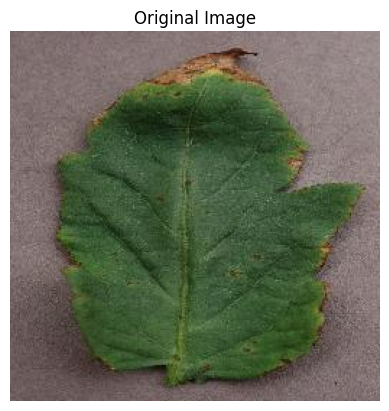

In [2]:
# Set a sample image path (update as needed)
sample_image_path = os.path.join(project_root, 'data', 'train')
first_class = [d for d in sorted(Path(sample_image_path).iterdir()) if d.is_dir()][0]
first_image = list(first_class.glob('*'))[0]
print('Sample image:', first_image)

# Load and show the original image
img = Image.open(first_image).convert('RGB')
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

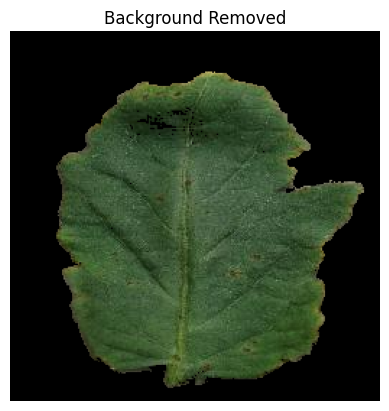

In [3]:
# Show background-removed version of the sample image
bg_removed = remove_background(str(first_image))
plt.imshow(bg_removed)
plt.title('Background Removed')
plt.axis('off')
plt.show()

## 3. Explore Raw Features

Let's extract and display some basic features from the sample image, such as mean and standard deviation of pixel values.

In [4]:
# Compute mean and std for original and background-removed images
img_np = np.asarray(img)
bg_removed_np = np.asarray(bg_removed)

features = {
    'original_mean': img_np.mean(axis=(0,1)),
    'original_std': img_np.std(axis=(0,1)),
    'bg_removed_mean': bg_removed_np.mean(axis=(0,1)),
    'bg_removed_std': bg_removed_np.std(axis=(0,1)),
}
display(pd.DataFrame(features, index=['R', 'G', 'B']))

,original_mean,original_std,bg_removed_mean,bg_removed_std
R,93.548264,37.295787,31.685791,33.843027
G,98.689682,22.390979,44.619598,45.886377
B,79.055206,34.429985,26.062958,28.068742


## 4. Apply Feature Engineering Functions

Now let's apply augmentations and visualize the results.

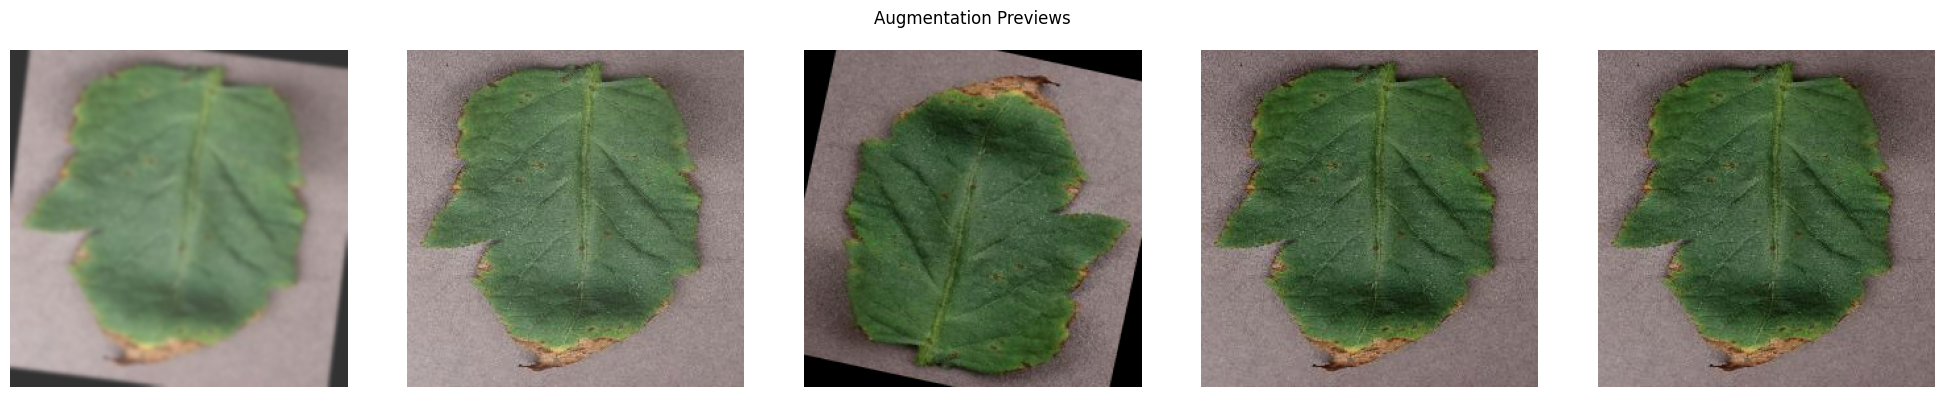

In [5]:
# Apply and visualize augmentations on the sample image
augmented_imgs = []
for i in range(5):
    augmented = train_transform(image=np.asarray(img))['image']
    augmented_imgs.append(augmented)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, aug_img in zip(axes, augmented_imgs):
    ax.imshow(aug_img)
    ax.axis('off')
fig.suptitle('Augmentation Previews')
plt.tight_layout()
plt.show()

## 5. Create New Features

Let's extract color histograms as additional features from the sample image.

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
R_hist,2.0,45.0,302.0,839.0,1634.0,3176.0,5472.0,7092.0,6571.0,4701.0,...,55.0,29.0,8.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0
G_hist,3.0,3.0,28.0,95.0,224.0,608.0,1132.0,1903.0,3169.0,5227.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B_hist,83.0,343.0,990.0,2232.0,4136.0,6053.0,7311.0,6752.0,4922.0,3317.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


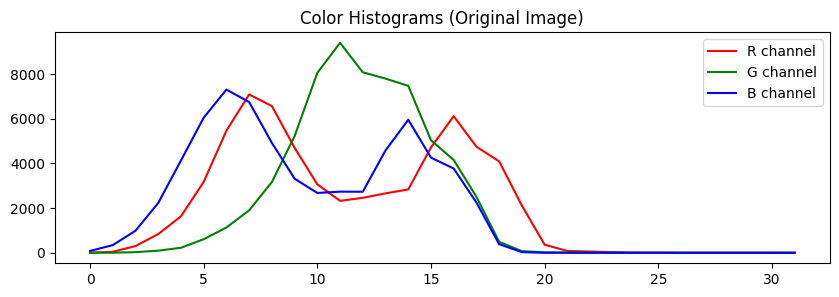

In [6]:
# Extract color histograms for each channel
hist_features = {}
for i, color in enumerate(['R', 'G', 'B']):
    hist = cv2.calcHist([np.asarray(img)], [i], None, [32], [0, 256]).flatten()
    hist_features[f'{color}_hist'] = hist

hist_df = pd.DataFrame(hist_features)
display(hist_df.T)

plt.figure(figsize=(10,3))
for i, color in enumerate(['R', 'G', 'B']):
    plt.plot(hist_features[f'{color}_hist'], color=color.lower(), label=f'{color} channel')
plt.legend()
plt.title('Color Histograms (Original Image)')
plt.show()

## 6. Evaluate Engineered Features

You can now use these features for further analysis or as input to machine learning models. For example, you can compare feature distributions across classes or use them for simple classification tasks.